<a href="https://colab.research.google.com/github/shreyshi11/Skin-Cancer-Detection/blob/main/MobileNetV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install -q -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.7 MB/s eta 0:00:00


In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_267addb2d43a0016e95b68fda8971d12"

In [ ]:
!kaggle datasets list -s "skin cancer"

ref                                                               title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
kmader/skin-cancer-mnist-ham10000                                 Skin Cancer MNIST: HAM10000                    5582914511  2018-09-20 20:36:13.037000         285593       2402  0.7058824        
surajghuwalewala/ham1000-segmentation-and-classification          Skin cancer: HAM10000                          2781385274  2021-05-27 09:08:46.813000          21294        156  0.9411765        
nodoubttome/skin-cancer9-classesisic                              Skin Cancer ISIC                               1647873564  2019-08-26 18:59:21.257000          36098        317  0.75             
farjanakabirsam

In [ ]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:36<00:00, 151MB/s]



In [ ]:
!unzip -q skin-cancer-mnist-ham10000.zip -d /content/ham10000

In [ ]:
import os

dataset_path = "/content/ham10000"

print(os.listdir(dataset_path))

['ham10000_images_part_1', 'HAM10000_images_part_2', 'hmnist_8_8_L.csv', 'HAM10000_metadata.csv', 'HAM10000_images_part_1', 'hmnist_28_28_L.csv', 'ham10000_images_part_2', 'hmnist_28_28_RGB.csv', 'hmnist_8_8_RGB.csv']


In [ ]:
import pandas as pd

metadata_path = "/content/ham10000/HAM10000_metadata.csv"

df = pd.read_csv(metadata_path)

print("Number of images:", len(df))
print("\nColumns:")
print(df.columns)

df.head()

Number of images: 10015

Columns:
Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
print(df['dx'].value_counts())

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
class_names = {
    'akiec': 'Actinic Keratoses',
    'bcc': 'Basal Cell Carcinoma',
    'bkl': 'Benign Keratosis',
    'df': 'Dermatofibroma',
    'mel': 'Melanoma',
    'nv': 'Melanocytic Nevi',
    'vasc': 'Vascular Lesions'
}

df['class_name'] = df['dx'].map(class_names)

print(df[['dx', 'class_name']].drop_duplicates().sort_values('dx'))

         dx            class_name
9687  akiec     Actinic Keratoses
2462    bcc  Basal Cell Carcinoma
0       bkl      Benign Keratosis
1095     df        Dermatofibroma
1211    mel              Melanoma
64       nv      Melanocytic Nevi
2320   vasc      Vascular Lesions


In [ ]:
import os

image_dir_1 = "/content/ham10000/HAM10000_images_part_1"
image_dir_2 = "/content/ham10000/HAM10000_images_part_2"

def get_image_path(image_id):
    path1 = os.path.join(image_dir_1, image_id + ".jpg")
    path2 = os.path.join(image_dir_2, image_id + ".jpg")

    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    else:
        return None

df['image_path'] = df['image_id'].apply(get_image_path)

print(df[['image_id', 'dx', 'image_path']].head())

       image_id   dx                                         image_path
0  ISIC_0027419  bkl  /content/ham10000/HAM10000_images_part_1/ISIC_...
1  ISIC_0025030  bkl  /content/ham10000/HAM10000_images_part_1/ISIC_...
2  ISIC_0026769  bkl  /content/ham10000/HAM10000_images_part_1/ISIC_...
3  ISIC_0025661  bkl  /content/ham10000/HAM10000_images_part_1/ISIC_...
4  ISIC_0031633  bkl  /content/ham10000/HAM10000_images_part_2/ISIC_...


In [ ]:
print("Missing images:", df['image_path'].isna().sum())

Missing images: 0


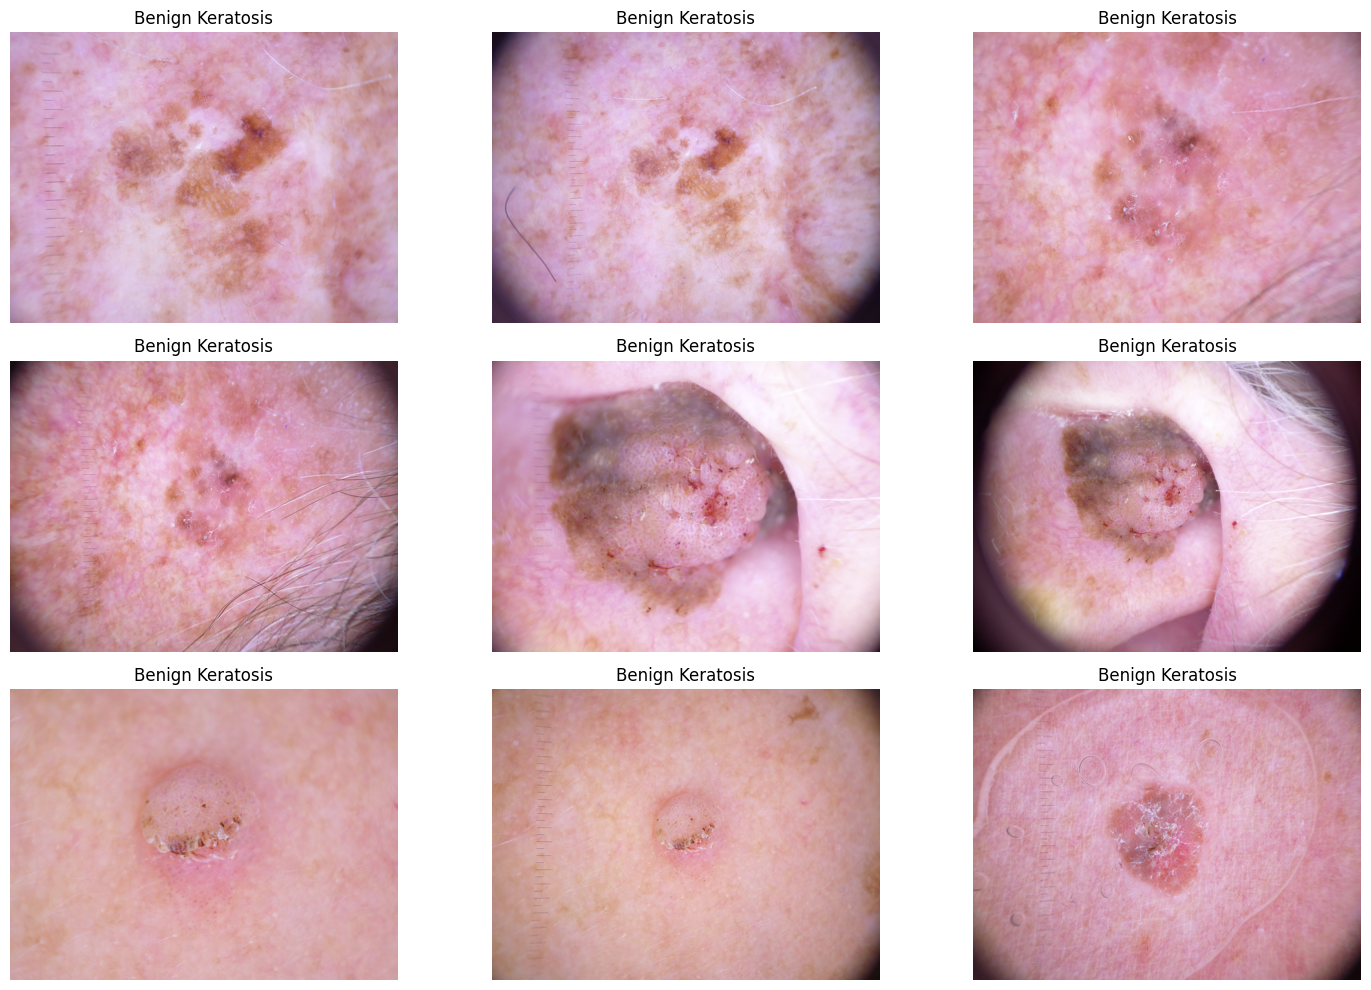

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(15, 10))

for i in range(9):
    sample = df.iloc[i]

    image = Image.open(sample['image_path'])

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(sample['class_name'])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
print(df['dx'].value_counts())

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
print("Missing images:", df['image_path'].isna().sum())

Missing images: 0


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# First: 80% train, 20% temporary
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, temp_idx = next(
    gss.split(
        df,
        groups=df['lesion_id']
    )
)

train_df = df.iloc[train_idx].copy()
temp_df = df.iloc[temp_idx].copy()

# Second: split the remaining 20% into 10% validation and 10% test
gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    gss2.split(
        temp_df,
        groups=temp_df['lesion_id']
    )
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

Training images: 7991
Validation images: 1025
Testing images: 999
Total: 10015


In [ ]:
print("TRAIN:")
print(train_df['dx'].value_counts())

print("\nVALIDATION:")
print(val_df['dx'].value_counts())

print("\nTEST:")
print(test_df['dx'].value_counts())

TRAIN:
dx
nv       5369
mel       877
bkl       856
bcc       424
akiec     260
vasc      108
df         97
Name: count, dtype: int64

VALIDATION:
dx
nv       678
mel      134
bkl      102
bcc       47
akiec     31
vasc      24
df         9
Name: count, dtype: int64

TEST:
dx
nv       658
bkl      141
mel      102
bcc       43
akiec     36
vasc      10
df         9
Name: count, dtype: int64


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_df['dx'])

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['dx']
)

class_weights = dict(
    zip(classes, class_weights_array)
)

print("Class weights:")
for cls, weight in class_weights.items():
    print(f"{cls}: {weight:.4f}")

Class weights:
akiec: 4.3907
bcc: 2.6924
bkl: 1.3336
df: 11.7688
mel: 1.3017
nv: 0.2126
vasc: 10.5701


In [ ]:
class_labels = [
    'akiec',
    'bcc',
    'bkl',
    'df',
    'mel',
    'nv',
    'vasc'
]

label_to_index = {
    label: index
    for index, label in enumerate(class_labels)
}

index_to_label = {
    index: label
    for label, index in label_to_index.items()
}

print(label_to_index)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [ ]:
# Convert class weights from class names to integer indices

class_weights_int = {
    label_to_index[label]: weight
    for label, weight in class_weights.items()
}

print("Integer class weights:")
print(class_weights_int)

Integer class weights:
{0: np.float64(4.390659340659341), 1: np.float64(2.6923854447439353), 2: np.float64(1.333611481975968), 3: np.float64(11.76877761413844), 4: np.float64(1.3016777976869196), 5: np.float64(0.21262272836122714), 6: np.float64(10.57010582010582)}


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 7

In [ ]:
import tensorflow as tf

def create_dataset(dataframe, shuffle=False):

    image_paths = dataframe['image_path'].values

    labels = dataframe['dx'].map(label_to_index).values

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    def load_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
        image = tf.cast(image, tf.float32)

        return image, label

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [ ]:
train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

In [ ]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image pixel range:", images.numpy().min(), "to", images.numpy().max())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image pixel range: 0.27377248 to 254.8479


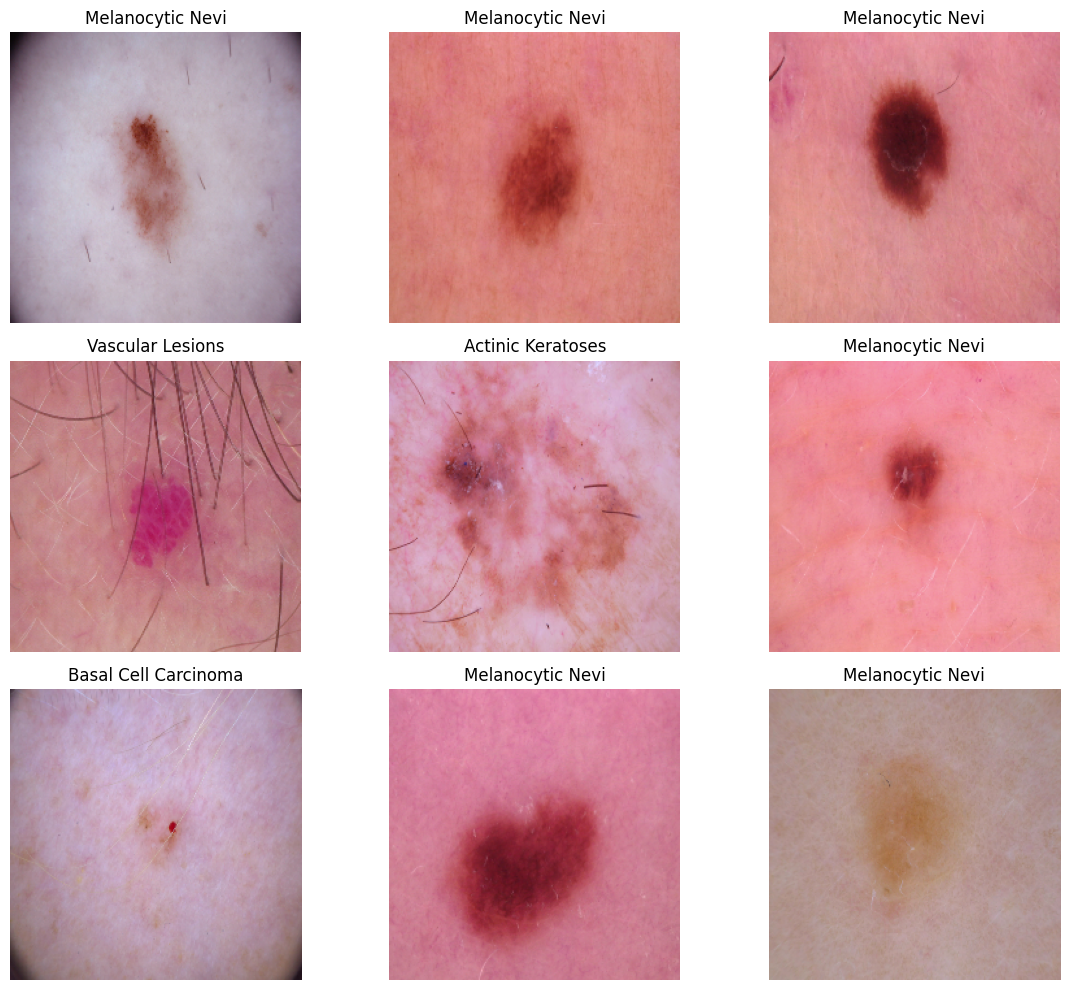

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i].numpy().astype("uint8"))

    label_index = labels[i].numpy()
    label = index_to_label[label_index]

    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")


# Load MobileNetV2 with ImageNet weights
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the base model initially
base_model.trainable = False


# Build complete model
inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

# MobileNetV2 expects preprocessing to [-1, 1]
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = models.Model(inputs, outputs)


model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        "mobilenetv2_skin_cancer_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Convert training labels to integer indices
y_train = train_df["dx"].map(label_to_index).astype(int).values

# Integer class IDs: 0,1,2,3,4,5,6
class_ids = np.arange(NUM_CLASSES)

# Calculate balanced weights
weights = compute_class_weight(
    class_weight="balanced",
    classes=class_ids,
    y=y_train
)

# IMPORTANT: keys are integers, not strings
class_weights_int = {
    int(class_id): float(weight)
    for class_id, weight in zip(class_ids, weights)
}

print(class_weights_int)
print("Key types:", [type(k) for k in class_weights_int.keys()])

{0: 4.390659340659341, 1: 2.6923854447439353, 2: 1.333611481975968, 3: 11.76877761413844, 4: 1.3016777976869196, 5: 0.21262272836122714, 6: 10.57010582010582}
Key types: [<class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>]


In [ ]:
print(label_to_index)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [ ]:
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights_int,
    callbacks=callbacks
)

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3489 - loss: 1.9848
Epoch 1: val_loss improved from None to 1.75809, saving model to mobilenetv2_skin_cancer_best.keras

Epoch 1: finished saving model to mobilenetv2_skin_cancer_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 75s 115ms/step - accuracy: 0.4066 - loss: 1.7274 - val_accuracy: 0.3268 - val_loss: 1.7581 - learning_rate: 0.0010
Epoch 2/15
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.4933 - loss: 1.2871
Epoch 2: val_loss improved from 1.75809 to 1.24998, saving model to mobilenetv2_skin_cancer_best.keras

Epoch 2: finished saving model to mobilenetv2_skin_cancer_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 58s 85ms/step - accuracy: 0.5288 - loss: 1.2815 - val_accuracy: 0.5337 - val_loss: 1.2500 - learning_rate: 0.0010
Epoch 3/15
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5708 - loss: 1.1904
Epoch 3: val_loss improved from 1.24998 to 0.99966, saving model to mobilenetv2_skin_cancer_best.keras

Epoch

In [ ]:
# Unfreeze the MobileNetV2 base model
base_model.trainable = True

# Freeze the earlier layers
# Only the last 30 layers will be trainable
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Check how many layers are trainable
trainable_layers = sum(
    1 for layer in base_model.layers if layer.trainable
)

print("Total MobileNetV2 layers:", len(base_model.layers))
print("Trainable MobileNetV2 layers:", trainable_layers)

Total MobileNetV2 layers: 154
Trainable MobileNetV2 layers: 19


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")

Model recompiled for fine-tuning.


In [ ]:
fine_tune_callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "mobilenetv2_skin_cancer_finetuned_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
FINE_TUNE_EPOCHS = 15

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights_int,
    callbacks=fine_tune_callbacks
)

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6006 - loss: 1.0273
Epoch 1: val_loss improved from None to 1.14372, saving model to mobilenetv2_skin_cancer_finetuned_best.keras

Epoch 1: finished saving model to mobilenetv2_skin_cancer_finetuned_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 73s 105ms/step - accuracy: 0.6052 - loss: 1.0473 - val_accuracy: 0.5766 - val_loss: 1.1437 - learning_rate: 1.0000e-05
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6251 - loss: 0.9509
Epoch 2: val_loss improved from 1.14372 to 1.13500, saving model to mobilenetv2_skin_cancer_finetuned_best.keras

Epoch 2: finished saving model to mobilenetv2_skin_cancer_finetuned_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 66s 117ms/step - accuracy: 0.6184 - loss: 0.9441 - val_accuracy: 0.5756 - val_loss: 1.1350 - learning_rate: 1.0000e-05
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.6326 - loss: 0.8966
Epoch 3: val_loss improved from 1.13500 to 1.04501, saving m

In [ ]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 229ms/step - accuracy: 0.6547 - loss: 0.9065

Test Loss: 0.9064723253250122
Test Accuracy: 0.6546546816825867


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Store true labels and predictions
y_true = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_prob.extend(probs)

# Convert to numpy arrays
y_true = np.array(y_true)
y_prob = np.array(y_prob)

# Get predicted class
y_pred = np.argmax(y_prob, axis=1)

# Class names
class_names = {
    'akiec': 'Actinic Keratoses',
    'bcc': 'Basal Cell Carcinoma',
    'bkl': 'Benign Keratosis',
    'df': 'Dermatofibroma',
    'mel': 'Melanoma',
    'nv': 'Melanocytic Nevi',
    'vasc': 'Vascular Lesions'
}

target_names = [class_names[label] for label in class_labels]

# Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    digits=4
))

                      precision    recall  f1-score   support

   Actinic Keratoses     0.2857    0.2222    0.2500        36
Basal Cell Carcinoma     0.4151    0.5116    0.4583        43
    Benign Keratosis     0.4512    0.6879    0.5449       141
      Dermatofibroma     0.1852    0.5556    0.2778         9
            Melanoma     0.3212    0.6078    0.4203       102
    Melanocytic Nevi     0.9596    0.6854    0.7996       658
    Vascular Lesions     0.6923    0.9000    0.7826        10

            accuracy                         0.6547       999
           macro avg     0.4729    0.5958    0.5048       999
        weighted avg     0.7653    0.6547    0.6856       999



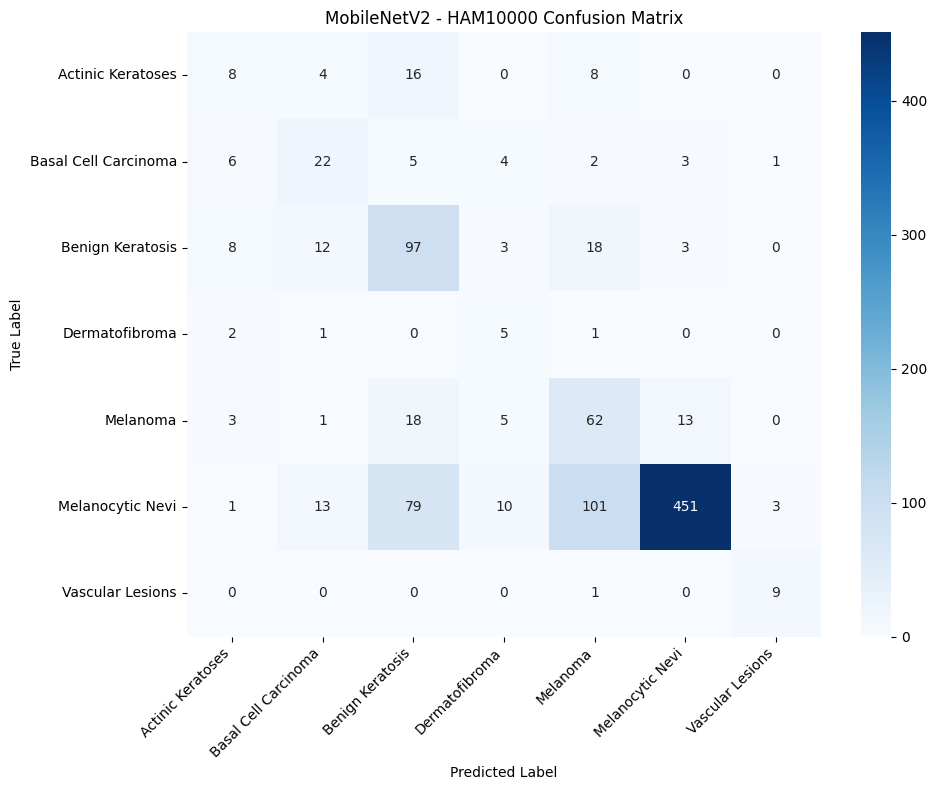

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV2 - HAM10000 Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

files.download("mobilenetv2_skin_cancer_finetuned_best.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!git clone https://github.com/shreyshi11/Skin-Cancer-Detection.git

Cloning into 'Skin-Cancer-Detection'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 49 (delta 13), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 19.34 MiB | 10.60 MiB/s, done.
Resolving deltas: 100% (13/13), done.


In [ ]:
%cd Skin-Cancer-Detection
!ls
!ls backend

/content/Skin-Cancer-Detection
backend					      README.md  Welcome_to_Colab.ipynb
index.html				      script.js
mobilenetv2_skin_cancer_finetuned_best.keras  style.css
main.py  requirements.txt


In [ ]:
!pip install -q fastapi uvicorn python-multipart pillow

In [ ]:
import tensorflow as tf

model_path = "/content/Skin-Cancer-Detection/mobilenetv2_skin_cancer_finetuned_best.keras"

model = tf.keras.models.load_model(model_path)

print("✅ Model loaded successfully!")
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

✅ Model loaded successfully!
Input shape: (None, 224, 224, 3)
Output shape: (None, 7)


In [ ]:
import subprocess
import time

server = subprocess.Popen(
    [
        "uvicorn",
        "backend.main:app",
        "--host", "0.0.0.0",
        "--port", "8000"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

print("Server status:", server.poll())

if server.poll() is not None:
    print("\n❌ Server stopped. Error:\n")
    print(server.stdout.read())
else:
    print("✅ FastAPI server is running!")

Server status: None
✅ FastAPI server is running!


In [ ]:
import requests

response = requests.get("http://127.0.0.1:8000/")

print("Status:", response.status_code)
print("Response:", response.json())

Status: 200
Response: {'message': 'Skin Cancer Detection API is running!'}


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'Skin-Cancer-Detection', 'images.jpg', 'sample_data']


In [ ]:
image_path = "/content/images.jpg"

In [ ]:
import requests

with open(image_path, "rb") as f:
    response = requests.post(
        "http://127.0.0.1:8000/predict",
        files={"file": f}
    )

print("Status:", response.status_code)
print("Response:", response.json())

Status: 200
Response: {'prediction': 'Melanocytic Nevi', 'confidence': 0.588893711566925, 'probabilities': {'Actinic Keratoses': 0.007132082711905241, 'Basal Cell Carcinoma': 0.0915500596165657, 'Benign Keratosis': 0.19820287823677063, 'Dermatofibroma': 0.052629392594099045, 'Melanoma': 0.04606964439153671, 'Melanocytic Nevi': 0.588893711566925, 'Vascular Lesions': 0.015522179193794727}}


In [ ]:
!python -m http.server 5500 --directory /content/Skin-Cancer-Detection &

Serving HTTP on 0.0.0.0 port 5500 (http://0.0.0.0:5500/) ...


In [ ]:
!pip install -q pyngrok

In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(5500)
print("Frontend URL:")
print(public_url)